<a href="https://colab.research.google.com/github/yuniecorn-dev/esaa_assignment2/blob/main/ESAA_OB_WEEK5_study_1002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##2.2 파이토치 기초 문법



###2.2.1 텐서 다루기

####텐서 생성 및 변환

In [2]:
# 텐서 생성
import torch
print(torch.tensor([[1,2], [3,4]])) # 2차원 형태의 텐서 생성
print(torch.tensor([[1,2], [3,4]], device="cuda:0")) # GPU에 텐서 생성
print(torch.tensor([[1,2], [3,4]], dtype=torch.float64)) # dtype을 이용하여 텐서 생성

tensor([[1, 2],
        [3, 4]])
tensor([[1, 2],
        [3, 4]], device='cuda:0')
tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)


In [5]:
# 텐서를 ndarray로 변환
temp = torch.tensor([[1,2], [3,4]])
print(temp.numpy()) # 텐서를 ndarray로 변환

temp = torch.tensor([[1,2], [3, 4]], device="cuda:0")
print(temp.to("cpu").numpy()) # GPU상의 텐서를 CPU의 텐서로 변환한 후 ndarray로 변환

[[1 2]
 [3 4]]
[[1 2]
 [3 4]]


####텐서의 인덱스 조작
- `torch. FloatTensor`: 32 비트의 부동 소수점
- `torch. DoubleTensor`: 64 비트의 부동 소수점
- `torch. LongTensor`: 64 비트의 부호가 있는 정수


In [6]:
temp = torch.FloatTensor([1, 2, 3, 4, 5, 6, 7]) # 파이토치로 1차원 벡터 생성
print(temp[0], temp[1], temp[-1]) # 인덱스로 접근
print('------------------------')
print(temp[2:5], temp[4:-2]) # 슬라이드로 접근

tensor(1.) tensor(2.) tensor(7.)
------------------------
tensor([3., 4., 5.]) tensor([5.])


####텐서 연산 및 차원 조작
- 다양한 수학적 연산 가능. GPU 사용하면 더 빠르게 가능.
- 텐서 간의 타입이 다르면 연산이 불가능

In [7]:
v = torch.tensor([1, 2, 3]) # 길이가 3인 벡터 생성
w = torch.tensor([3, 4, 6])
print(w - v) # 길이가 같은 벡터 간 뺄셈 연산

tensor([2, 2, 3])


In [8]:
# 텐서의 차원 조작: view 이용 (텐서 결합: stack, cat / 차원 교환: t, transpose)
temp = torch.tensor([
    [1, 2], [3, 4]]) # 2x2 행렬 생성

print(temp.shape)
print('------------------------')
print(temp.view(4, 1)) # 2x2 행렬을 4x1로 변형
print('------------------------')
print(temp.view(-1)) # 2x2 행렬을 4x1로 변형
print('------------------------')
print(temp.view(1, -1)) # 1은 (1,?)와 같은 의미로 다른 차원으로 부터 해당 값을 유추하겠다는 것.
#temp의 원소 개수를 유지한 채 (1,?)의 형태를 만족해야 하므로 (1,4)가 됨.
print('------------------------')
print(temp.view(-1, 1))

torch.Size([2, 2])
------------------------
tensor([[1],
        [2],
        [3],
        [4]])
------------------------
tensor([1, 2, 3, 4])
------------------------
tensor([[1, 2, 3, 4]])
------------------------
tensor([[1],
        [2],
        [3],
        [4]])


###2.2.2 데이터 준비
- 데이터 호출
  - 파이썬 라이브러리(pandas)를 이용하는 방법
  - 파이토치에서 제공하는 데이터를 이용하는 방법
- 이미지 데이터 (이미지 모델 사용)
  - 분산된 파일에서 데이터를 읽은 후 전처리를 하고 배치 단위로 분할하여 처리
- 텍스트 데이터 (텍스트 모델 사용)
  - 임베딩 과정을 거쳐 서로 다른 길이의 시퀀스를 배치 단위로 분할하여 처리

####단순하게 파일을 불러와서 사용

In [9]:
!pip install pandas

In [ ]:
import pandas as pd
import torch
data = pd.read_csv('class2.csv')

x = torch.from_numpy(data['x'].values).unsqueeze(dim=1).float()
y = torch.from_numpy(data['y'].values).unsqueeze(dim=1).float()

####커스텀 데이터셋을 만들어서 사용
- 데이터를 한 번에 다 부르지 않고 조금씩 나누어 불러서 사용하는 방식

In [ ]:
class CustomDataset(torch.utils.data.Dataset):
  def __init__(self): # 필요한 변수를 선언하고, 데이터셋의 전처리를 해 주는 함수
  def __len__(self): # 데이터셋의 길이, 총 샘플의 수를 가져오는 함수
  def __getitem__(self, index): # 데이터셋에서 특정 데이터를 가져오는 함수
   # (index번째 데이터를 반환하는 함수이며, 이때 반환되는 값은 텐서의 형태를 취해야 함.)

In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

class CustomDataset(Dataset):
  def __init__(self, csv_file):
    self.label = pd.read_csv(csv_file)

  def __len__(self):
    return len(self.label)

  def __getitem__(self, idx):
    sample = torch.tensor(self.label.iloc[idx, [0:3]).int()
    label = torch.tensor(self.label.iloc[idx, 3]).int()
    return sample, label

tensor_dataset = CustomDataset('covtype.csv')
dataset = DataLoader(tensor_dataset, batch_size=4, shuffle=True)

**torch.utils.data.DataLoader**
- DataLoader 객체는 학습에 사용될 데이터 전체를 보관했다가 모델 학습을 할 때 배치 크기만큼 데이터를 꺼내서 사용
- 데이터를 미리 잘라놓기 X. 내부적으로 반복자(iterator)에 포함된 index를 이용하여 배치 크기만큼 데이터 반환
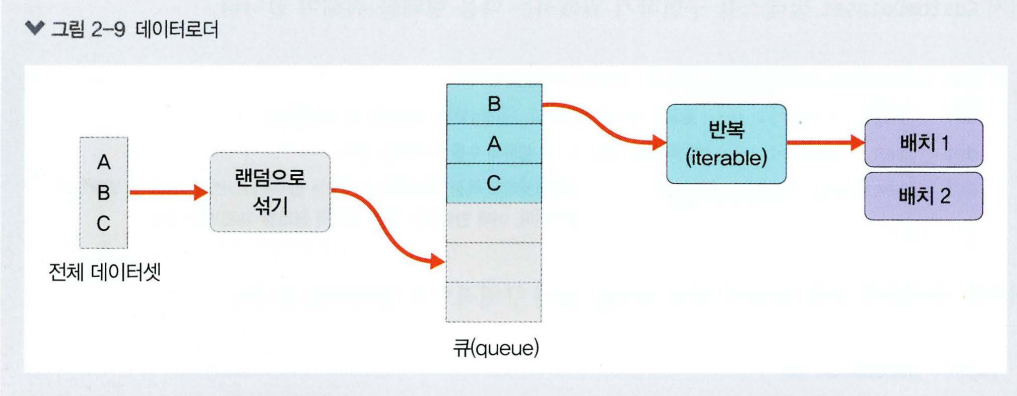

In [ ]:
# 데이터로더는 for문을 이용해 구문을 반복 실행하는 것과 같음.
for i, data in enumerate(dataset,0):
  print(i, end='')
  batch=data[0]
  print(batch.size())

####파이토치에서 제공하는 데이터셋 사용
https://pytorch.org/vision/O.8/datasets.html

In [11]:
!pip install requests

In [ ]:
import torchvision.transforms as transforms

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (1.0,))
]) # 평균이 0.5, 표준편차가 1.0이 되도록 데이터의 분포(normalize)를 조정

from torchvision.datasets import MNIST
import requests
download_root = '../chap02/data/MNIST_DATASET' # 내려받을 경로 지정

train_dataset = MNIST(download_root, transform=mnist_transform, train=True,
                      download=True) # 훈련(training) 데이터셋

valid_dataset = MNIST(download_root, transform=mnist_transform, train=False,
                      download=True) # 검증(validation) 데이터셋

test_dataset = MNIST(download_root, transform=mnist_transform, train=False,
                     download=True) # 테스트(test) 데이터셋

###2.3 모델 정의

- 계층(layer)
  - 모듈 또는 모듈을 구성하는 한 개의 계층
  - convolutional layer, linear layer 등이 있음.
- 모듈(module)
  - 한 개 이상의 계층이 모여서 구성된 것
  - 모듈이 모여 새로운 모듈을 만들 수도 있음.
- 모델(model)
  - 최종적으로 원하는 네트워크
  - 한 개의 모듈이 모델이 될 수도 있음.

####단순 신경망을 정의하는 방법

In [17]:
# nn.Module을 상속받지 않는 매우 단순한 모델을 만들 때 사용
# 구현이 쉽고 단순
model = nn.Linear(in_features=1, out_features=1, bias=True)

####nn.Module()을 상속하여 정의하는 방법
* nn.Module을 상속받는 모델은 기본적으로 `__init__()`과 `forward()` 함수를 포함함
* `__init__()`에서는 `nn.Linear`, `nn.Conv2d` 등의 모듈과 활성화 함수를 정의함
* `forward()`에서는 모델이 수행할 연산과 데이터의 흐름을 정의함

In [ ]:
class MLP(Module):
  def __init__(self, inputs):
    super(MLP, self).__init__()
    self.layer = Linear(inputs, 1) # 계층 정의
    self.activation = Sigmoid() # 활성화 함수 정의

  def forward(self, X):
    X = self.layer(X)
    X = self.activation(X)
    return X

####Sequential 신경망을 정의하는 방법

In [16]:
import torch.nn as nn
class MLP(nn.Module):
  def __init__(self):
    super(MLP, self).__init__()
    self.layer1 = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=64, kernel_size=5),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2))

    self.layer2 = nn.Sequential(
        nn.Conv2d(in_channels=64, out_channels=30, kernel_size=5),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2))

    self.layer3 = nn.Sequential(
        nn.Linear(in_features=30*5*5, out_features=10, bias=True),
        nn.ReLU(inplace=True))

    def forward(self, x):
      x = self.layer1(x)
      x = self.layer2(x)
      x = x.view(x.shape[0], -1)
      x = self.layer3(x)
      return x

model = MLP() # 모델이 대한 객체 생성

print("Printing children\n--------------------------")
print(list(model.children()))
print("\n\nPrinting Modules\n--------------------------")
print(list(model.modules()))

Printing children
--------------------------
[Sequential(
  (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
), Sequential(
  (0): Conv2d(64, 30, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
), Sequential(
  (0): Linear(in_features=750, out_features=10, bias=True)
  (1): ReLU(inplace=True)
)]


Printing Modules
--------------------------
[MLP(
  (layer1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(64, 30, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Linear(in_fea

####model.modules() & model.children()
- model.modules()
  - 모델의 네트워크에 대한 모든 노드를 반환
- model.children()
  - 같은 수준(level)의 하위 노드를 반환
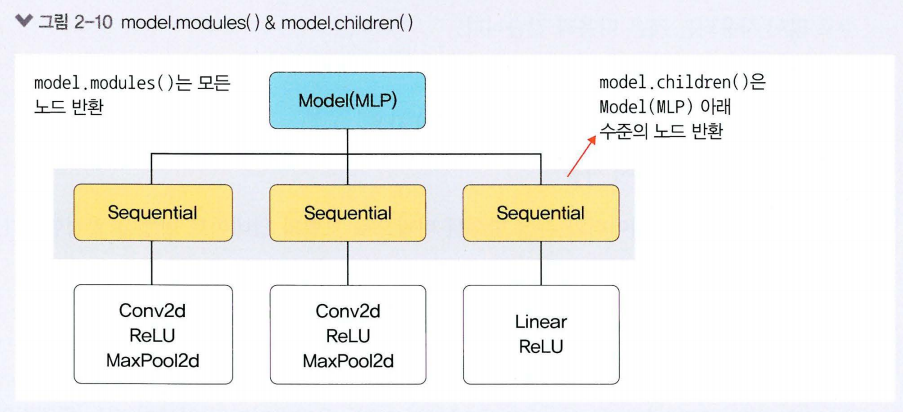

####함수로 신경망을 정의하는 방법

In [19]:
def MLP(in_features=1, hidden_features=20, out_features=1):
  hidden = nn.Linear(in_features=in_features, out_features=hidden_features, bias=True)
  activation = nn.ReLU()
  output = nn.Linear(in_features=hidden_features, out_features=out_features, bias=True)
  net = nn.Sequential(hidden, activation, output)
  return net

###2.2.4 모델의 파라미터 정의
- loss function
  - 학습하는 동안 출력과 실제 값(정답) 사이의 오차를 측정
    - BCELoss: 이진 분류를 위해 사용
    - CrossEntropyLoss: 다중 클래스 분류를 위해 사용
    - MSELoss: 회귀 모델에서 사용
- optimizer
  - 데이터와 손실함수를 바탕으로 모델의 업데이트 방법을 결정
     * Optimizer는 `step()`을 통해 모델의 파라미터를 업데이트하며 파라미터별로 다른 학습률을 적용할 수 있음
      * `Optimizer`는 옵티마이저의 기본 클래스이며 `zero_grad()`는 파라미터의 gradient를 0으로 초기화함
      * `lr_scheduler`는 에포크에 따라 학습률을 조절하는 기능을 제공함

- learning rate scheduler
  - 미리 지정한 횟수의 에포크를 지날 때마다 학습률을 감소시켜 줌.
    * `LambdaLR`, `StepLR`, `MultiStepLR`은 지정한 함수·단계·에포크에 따라 학습률을 감소시킴
    * `ExponentialLR`은 매 에포크마다 학습률에 감마를 곱하고, `CosineAnnealingLR`은 코사인 형태로 학습률을 변화시킴
    * `ReduceLROnPlateau`는 학습 성능이 개선되는지에 따라 학습률을 동적으로 조절함

- metrics
  - 훈련과 테스트 단계를 모니터링

####전역 최소점과 최적점
* 손실 함수는 실제 값과 예측 값의 차이를 수치화하며, 손실을 최소화하는 가중치와 바이어스를 찾는 것이 학습 목표임
* 전역 최소점은 오차가 가장 작은 최적점으로, 모델이 최종적으로 찾고자 하는 지점을 의미함
* 지역 최소점은 전역 최소점이 아닌 낮은 지점으로, 옵티마이저가 여기에 멈추면 최적의 오차를 찾지 못할 수 있음
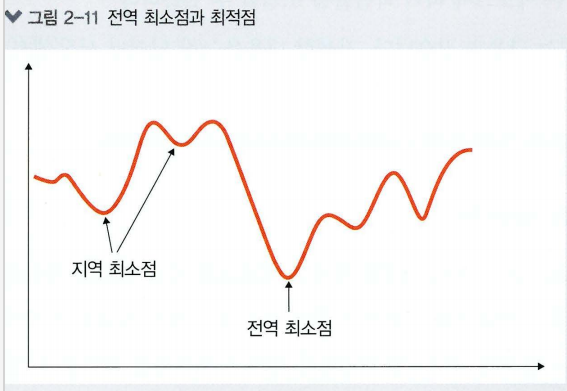

In [ ]:
from torch.optim import optimizer
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer=optimizer,
                                              lr_lambda=lambda epoch:0.95 ** epoch)
for epoch in range(1, 100+1):
  for x, y in dataloader:
    optimizer.zero_grad()
loss_fn(model(x), y).backward()
optimizer.step()
scheduler.step()

###2.2.5 모델 훈련

- 학습시킨다
  - y = wx + b라는 함수에서 w와 b의 적절한 값을 찾는다
  - w와 b에 임의의 값을 적용해 시작하며 오차가 줄어들어 전역 최소점에 이를 때까지 파라미터(w, b)를 계속 수정

* 훈련 시작 전 `optimizer.zero_grad()`를 호출해 이전에 누적된 기울기를 초기화함
* `loss.backward()`는 기울기를 계산하며, 파이토치는 기본적으로 새로운 기울기를 기존 값에 누적함
* 따라서 일반적인 모델에서는 매 학습 단계마다 `zero_grad()`로 기울기를 초기화해 불필요한 누적을 방지함

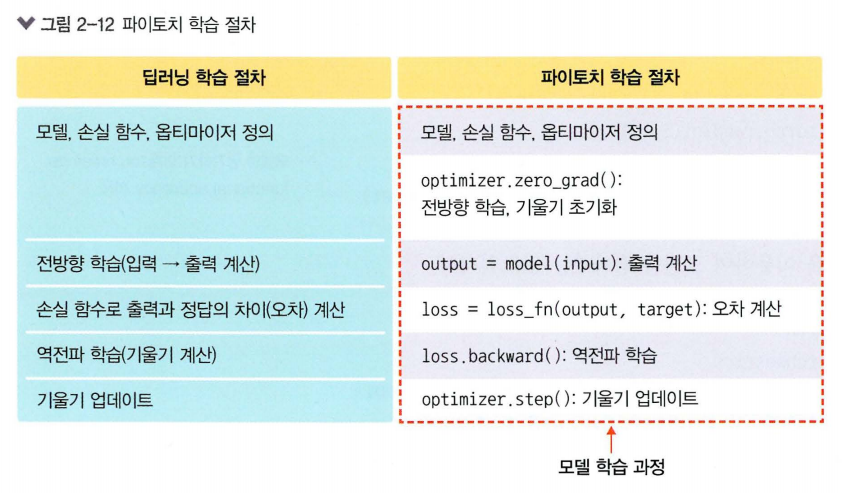


In [ ]:
for epoch in range(100):
  yhat = model(x_train)
  loss = criterion(yhat, y_train)
  optimizer.zero_grad() # 오차가 중립적으로 쌓이지 않도록 초기화
  loss.backward()
  optimizer.step()

###2.2.6 모델 평가


In [22]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.2 MB/s eta 0:00:00


In [24]:
# 함수를 이용하여 모델 평가
import torch
import torchmetrics

preds = torch.randn(10,5).softmax(dim=-1)
target = torch.randint(5, (10,))

acc = torchmetrics.functional.accuracy(preds, target, task='multiclass', num_classes=5)

In [25]:
# 모듈을 이용하여 모델 평가
import torch
import torchmetrics
metric = torchmetrics.Accuracy(task='multiclass', num_classes=5) # 모델 평가(정확도) 초기화

n_batches = 10
for i in range(n_batches):
  preds = torch.randn(10, 5).softmax(dim=-1)
  target = torch.randint(5, (10,))

  acc = metric(preds, target)
  print(f"Accuracy on batch {i}: {acc}") # 현재 배치에서 모델 평가(정확도)

acc = metric.compute()
print(f"Accuracy on all data: {acc}") # 모든 배치에서 모델 평가(정확도)

Accuracy on batch 0: 0.4000000059604645
Accuracy on batch 1: 0.20000000298023224
Accuracy on batch 2: 0.30000001192092896
Accuracy on batch 3: 0.10000000149011612
Accuracy on batch 4: 0.20000000298023224
Accuracy on batch 5: 0.30000001192092896
Accuracy on batch 6: 0.20000000298023224
Accuracy on batch 7: 0.10000000149011612
Accuracy on batch 8: 0.20000000298023224
Accuracy on batch 9: 0.20000000298023224
Accuracy on all data: 0.2199999988079071


###2.2.7 훈련 과정 모니터링
* 텐서보드는 학습 과정에서 각 파라미터의 변화를 시각적으로 모니터링할 수 있음
* 학습 성능을 추적하고 모델의 학습 과정을 평가하는 데 활용할 수 있음
* 다양한 파라미터와 학습 결과를 그래프로 시각화하여 쉽게 확인할 수 있음
________________________
[파이토치에서 텐서보드 사용법]
1. 텐서보드를 설정(set up)
2. 텐서보드에 기록(write)
3. 텐서보드를 사용하여 모델 구조를 살펴봄.

In [27]:
!pip install tensorboard

In [ ]:
import torch
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter("../chap02/tensorboard") # 모니터링에 필요한 값들이 저장될 위치

for epoch in range(num_epochs):
    model.train() # 학습 모드로 전환(dropout=True)
    batch_loss = 0.0

    for i, (x, y) in enumerate(dataloader):
        x, y = x.to(device).float(), y.to(device).float()
        outputs = model(x)
        loss = criterion(outputs, y)
        writer.add_scalar("Loss", loss, epoch) # 스칼라 값(오차)을 기록
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

writer.close() # SummaryWriter가 더 이상 필요하지 않으면 close() 메서드 호출

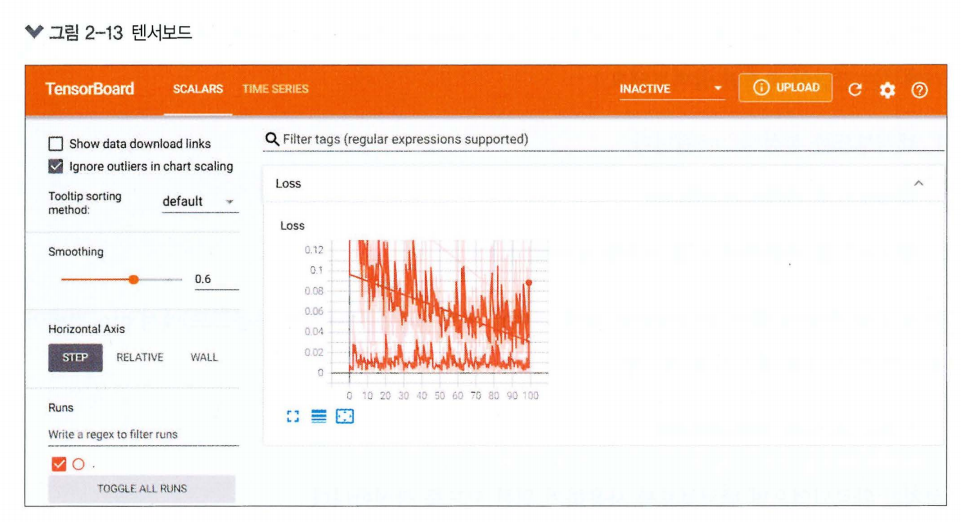

####model.train() & model.eval()
* `model.train()`은 훈련 모드로 전환하여 드롭아웃 등을 활성화하고 훈련 데이터에 사용함
* `model.eval()`은 평가 모드로 전환하여 검증·테스트 데이터에 사용하며, 모든 노드를 사용함
* 평가 시 `torch.no_grad()`를 사용하면 기울기 계산을 하지 않아 메모리와 연산 시간을 줄일 수 있음


In [ ]:
with torch.no_grad():
  valid_loss = 0

  for x, y in valid_dataloader:
    outputs = model(x)
    loss = F.cross_entropy(outputs, y.long().squeeze())
    valid_loss += float(loss)
    y_hat += [outputs]

valid_loss = valid_loss / len(valid_loader)